In [233]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chisquare
from scipy import stats
import seaborn as sns
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm


In [150]:
df1 = pd.DataFrame(pd.read_csv("data-files/lotto.csv", header=None))
df2 = pd.DataFrame(pd.read_csv("data-files/lotto2.csv", header=None))
columns = ['n1', 'n2', 'n3', 'n4', 'n5', 'n6', 'count']
df1.columns = columns
df2.columns = columns
df1.astype(dtype='int64')


,n1,n2,n3,n4,n5,n6,count
0,1,10,20,33,37,38,2307103
1,17,22,25,26,30,34,3013593
2,7,9,17,26,38,43,15295888
3,12,28,32,35,39,44,2592896
4,10,19,23,35,36,42,6840443
...,...,...,...,...,...,...,...
607,14,17,23,25,37,41,4160960
608,16,18,21,26,29,40,1797438
609,8,20,26,31,33,44,753033
610,7,23,29,33,36,45,11246433


In [151]:
df2

,n1,n2,n3,n4,n5,n6,count
0,3,11,15,29,33,42,2592983
1,5,15,19,21,23,28,4146951
2,3,12,13,16,22,25,2622050
3,5,15,16,23,33,45,4138816
4,4,8,21,23,29,35,3200478
...,...,...,...,...,...,...,...
666,3,4,19,36,38,45,2134820
667,8,10,16,17,31,37,5468517
668,5,25,28,32,42,45,4288506
669,3,10,12,13,20,42,2528458


20.46023272481774 0.008728245813362437
→ 데이터가 벤포드 법칙을 따르지 않을 가능성이 높습니다.


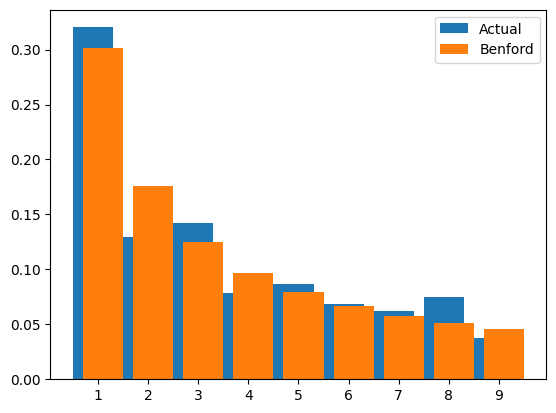

In [222]:
# 분포/비율 비교 검정(카이제곱 검정)

df = df1

sumArr = [0,0,0,0,0,0,0,0,0,0,0]

for value in df["count"]:
    sumArr[int(str(value)[0])] += 1
    # for value in df.loc[idx]:
        

observed = np.array(sumArr[1:10])
benford = np.log10(1 + 1 / np.arange(1,10))
expected = benford * observed.sum()

chi_stat, p_value = chisquare(f_obs=observed, f_exp=expected)

print(chi_stat, p_value)

if p_value < 0.05:
    print("→ 데이터가 벤포드 법칙을 따르지 않을 가능성이 높습니다.")
else:
    print("→ 데이터가 벤포드 법칙을 따른다고 볼 수 있습니다.")


df_result = [count / sum(sumArr[1:10]) for count in sumArr[1:10]]

plt.bar(np.arange(1, 10) - 0.1, df_result, label='Actual', align='center')
plt.bar(np.arange(1, 10) + 0.1, benford, label='Benford', align='center')
plt.xticks(np.arange(1,10))
plt.legend()
plt.show()

-0.9747762310498298 0.33005702779417967
→ 데이터가 평균을 따른다고 볼 수 있습니다.


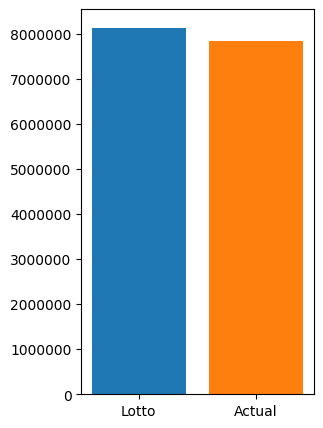

In [224]:
# 평균 비교 검정(t 검정)

df = df1

lotto_mean = 8145060
df_mean = df["count"].mean()

t_stat, p_value =stats.ttest_1samp(df["count"], lotto_mean)

print(t_stat, p_value)
if p_value < 0.05:
    print("→ 데이터가 평균을 따르지 않을 가능성이 높습니다.")
else:
    print("→ 데이터가 평균을 따른다고 볼 수 있습니다.")

plt.figure(figsize=(3, 5))
plt.ticklabel_format(style='plain', axis='y')
plt.bar(x='Lotto', height=lotto_mean, align='center')
plt.bar(x='Actual', height=df_mean, align='center')
plt.show()



11.363679984528714 2.7925645349286485e-27
→ 데이터가 유의미한 차이가 있습니다.
7838622.096405229 4118809.475490196


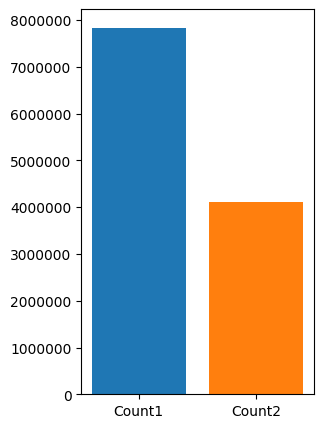

In [231]:
# 대응/쌍 비교 검정(Paired t-test)

valueRange = len(df1) if len(df1) < len(df2) else len(df2)
count1 = df1["count"][:valueRange]
count2 = df2["count"][:valueRange]

pt_stat, p_value = stats.ttest_rel(count1, count2)

print(pt_stat, p_value)
if p_value < 0.05:
    print("→ 데이터가 유의미한 차이가 있습니다.")
else:
    print("→ 데이터가 유의미한 차이가 있지 않습니다.")

print(count1.mean(), count2.mean())
plt.figure(figsize=(3, 5))
plt.ticklabel_format(style='plain', axis='y')
plt.bar(x='Count1', height=count1.mean(), align='center')
plt.bar(x='Count2', height=count2.mean(), align='center')
plt.show()

count  V1  V2  V3  V4  V5
row_0                    
C1     16   4   1   0   0
C2     53  45  25   7   0
C3     61  61  71  68  33
C4      4  23  35  56  72
C5      1   1   2   3  29
299.43870862040103 3.333294333095783e-54 16
→ 데이터가 통계적으로 유의미한 관계가 있습니다.


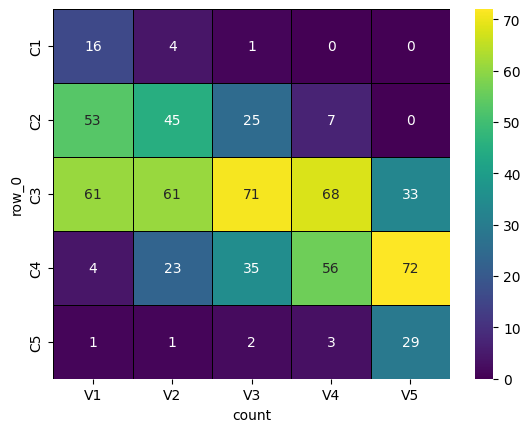

In [210]:
# 독립성/관련성 검정 (Chi-square 독립성 검정)

df = df2

sum_of_numbers = df.iloc[:, :6].sum(axis=1) # 각 행의 n1~n6 합계
lotto_count = df.iloc[:, 6]
sum_bins = pd.cut(sum_of_numbers, bins=5, labels=[f'C{i+1}' for i in range(5)])
count_bins = pd.qcut(lotto_count, q=5, labels=[f'V{i+1}' for i in range(5)], duplicates='drop')

contingency_table = pd.crosstab(sum_bins, count_bins)

chi2_stat, p_value, df_dof, expected_frequencies = stats.chi2_contingency(contingency_table)

print(contingency_table)
print(chi2_stat, p_value, df_dof)

if p_value < 0.05:
    print("→ 데이터가 통계적으로 유의미한 관계가 있습니다.")
else:
    print("→ 데이터가 통계적으로 유의미한 관계가 있지 않습니다.")

sns.heatmap(contingency_table, annot=True, fmt='d', cmap='viridis', linewidths=.5, linecolor='black')
plt.show()

0.6525266486960903 1.2092175794695965e-82
→ 데이터가 0.653만큼의 선형 관계를 가집니다.


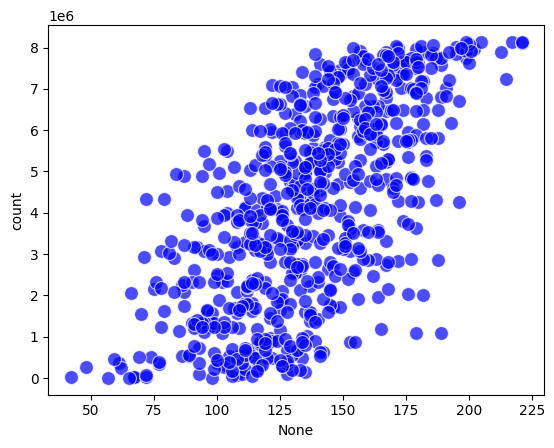

In [235]:
#회귀 및 상관 검정 

df = df2

data = [
    df.iloc[:, :6].sum(axis=1),
    df.iloc[:, 6]
]

correlation, p_value = stats.pearsonr(data[0], data[1])

print(correlation, p_value)
if p_value < 0.05:
    print(f"→ 데이터가 {correlation:.3f}만큼의 선형 관계를 가집니다.")
else:
    print("→ 데이터가 선형 관계를 가지지 않습니다.")


sns.scatterplot(x=data[0], y=data[1], s=100, alpha=0.7, color='blue')
plt.show()
